# Parameter Recovery via Laplace + VBMC — (length_scale, mu_0) sweep

Condition-stratified, WITH Beta-mixture linking function (shapes shared and fixed at truth).

Structure:
0. Fixed geometry & constants (parameter-independent)
1. `generate_data(true_ls, true_mu, seed)` — synthetic ratings for any ground truth
2. Laplace marginal likelihood `log Z(theta)` machinery
3-5. One-off diagnostics at the REFERENCE setting: coherence-mode sanity check, objective slices, 1-D (ls-only / mu-only) VBMC recoveries
6. Sweep: joint (ls, mu) VBMC recovery at every grid point, saved incrementally to `results/param-recovery-vbmc-laplace/`
7. Summary: recovered-vs-true plots across the grid


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")   # float64 for stable log-det / Cholesky

import sys, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.stats import beta as jbeta
import matplotlib.pyplot as plt
from pyvbmc import VBMC

from model_jax import rbf_kernel, p_u_given_y, _mvn_logpdf_chol   # GP kernel + speaker + stable MVN

print(f"backend: {jax.default_backend()}  x64: {jax.config.jax_enable_x64}")

backend: cpu  x64: True


## Fixed constants and feature geometry

Real feature embeddings and per-condition trained regions (parameter-independent).
`output_scale`, `beta`, and the Beta-mixture linking shapes are FIXED at truth throughout;
only `(length_scale, mu_0)` vary across the sweep.


In [2]:
# Parameters held FIXED at truth during all recoveries
FIXED_PARAMS = {'output_scale': 1.5, 'beta': 3.0}

# True Beta-mixture linking shapes, SHARED across conditions/features, FIXED during recovery.
# [a_kl, b_kl, a_nkl, b_nkl]: kl = high-mean "kind-linked" component (mean 0.8), nkl = low-mean
# "not-kind-linked" component (mean 0.2). Coherence pz1 = sigmoid(y_test) is the MIXTURE WEIGHT.
TRUE_LINK_SHAPES = np.array([8.0, 2.0, 2.0, 8.0])

# Reference setting for the one-off diagnostics (sections 3-4); the sweep grid is defined
# in section 5. ls=0.4 is in the identifiable regime (< cloud diameter ~0.78).
REF_LS, REF_MU = 0.4, 0.5

with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)
train_df = df[df.split == 'train']
feat_idx = df.set_index('feature')

CONDITIONS  = ['diet', 'personality', 'physical', 'heterogeneous']
CAT_OF_COND = {'diet':'diet_preferences', 'personality':'personality_behaviors', 'physical':'physical'}
CAT_SHORT   = {'diet_preferences':'diet', 'personality_behaviors':'personality', 'physical':'physical'}

x_train_cond, u_train_cond = {}, {}
for c in CONDITIONS:
    sub = train_df[train_df.in_heterogenous] if c == 'heterogeneous' else train_df[train_df.category == CAT_OF_COND[c]]
    x_train_cond[c] = jnp.array(sub[['x_2d', 'y_2d']].values)
    u_train_cond[c] = jnp.zeros(len(sub), dtype=jnp.int32)   # all generic, localized to the region -- fixed by design
    print(f"  {c:<14}: {len(sub)} trained features")

CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':'can eat spicy food','diet_breakfast_late_1':'eat breakfast very late',
    'diet_five_meals_day_1':'eat five meals a day','diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':'put pepper on all their foods','pers_cry_easily_1':'cry easily',
    'pers_collect_rocks_1':'like to collect rocks','pers_like_to_dance_1':'like to dance',
    'pers_like_highfive_1':'like to give high-fives','pers_read_books_1':'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue','phys_can_snap_toes_1':'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears','phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':'snore when they sleep'}
TEST_CSV_COLS      = list(CSV_TO_FEATURE.keys())
test_feature_names = list(CSV_TO_FEATURE.values())
x_test     = jnp.array([feat_idx.loc[n, ['x_2d','y_2d']].values for n in test_feature_names])  # (J,2)
test_trait = [CAT_SHORT[feat_idx.loc[n, 'category']] for n in test_feature_names]
J = x_test.shape[0]

a_kl, b_kl, a_nkl, b_nkl = TRUE_LINK_SHAPES
print(f"Linking shapes: kl=Beta({a_kl},{b_kl}) mean={a_kl/(a_kl+b_kl):.2f}, "
      f"nkl=Beta({a_nkl},{b_nkl}) mean={a_nkl/(a_nkl+b_nkl):.2f}")


  diet          : 15 trained features
  personality   : 15 trained features
  physical      : 15 trained features
  heterogeneous : 15 trained features
Linking shapes: kl=Beta(8.0,2.0) mean=0.80, nkl=Beta(2.0,8.0) mean=0.20


## 1. Synthetic data generation — `generate_data(true_ls, true_mu, seed)`

One independent GP coherence field per condition over `[x_test, x_train_cond[c]]` at the given
truth, then per-participant ratings from the 2-component Beta mixture where the coherence
`pz1 = sigmoid(y_test)` is the mixture weight.


  diet          : y_test range [-1.72, 0.50]  pz1 range [0.15, 0.62]  (realized mean y_test=-0.636)
  personality   : y_test range [-0.50, 1.01]  pz1 range [0.38, 0.73]  (realized mean y_test=0.492)
  physical      : y_test range [-0.56, 1.76]  pz1 range [0.36, 0.85]  (realized mean y_test=0.622)
  heterogeneous : y_test range [-1.52, 0.69]  pz1 range [0.18, 0.67]  (realized mean y_test=-0.089)


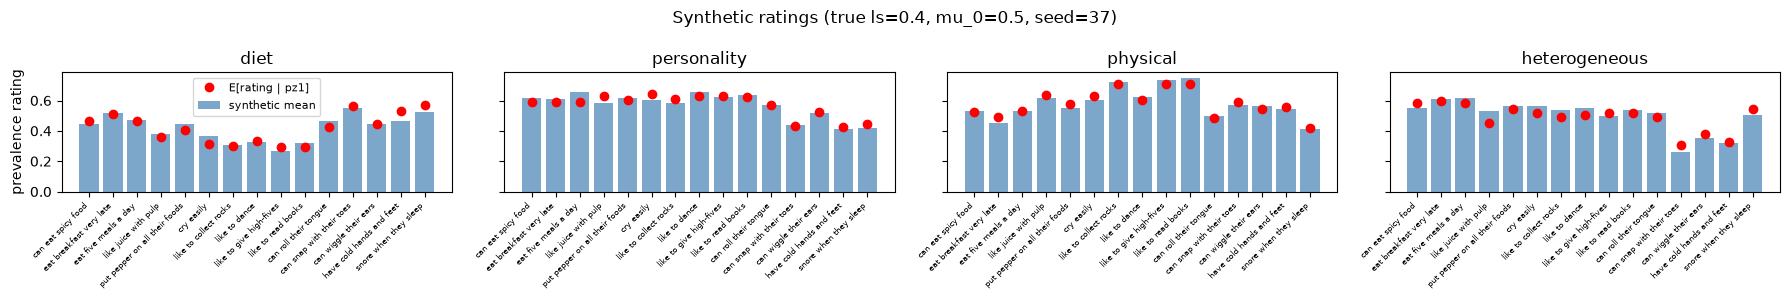

In [3]:
N_PARTICIPANTS_COND = {'diet': 100, 'personality': 100, 'physical': 100, 'heterogeneous': 100}
H = 1.0 / 200.0   # half a slider bin -- used to nudge exact 0/1 responses inward for Beta.logpdf

def generate_data(true_ls, true_mu, seed=37, verbose=False):
    '''Synthetic per-condition coherence fields + Beta-mixture ratings at the given ground truth.

    Returns dict with y_test_true_cond, pz1_test_true_cond, responses_cond, plus the truth itself.'''
    rng = np.random.default_rng(seed)
    a_kl, b_kl, a_nkl, b_nkl = TRUE_LINK_SHAPES

    y_test_true_cond, pz1_test_true_cond, responses_cond = {}, {}, {}
    for c in CONDITIONS:
        # test first then train (matches the GP density convention) -- one independent
        # GP draw PER CONDITION, since each condition has its own trained region / coherence field.
        n_train_c = x_train_cond[c].shape[0]
        X_all = jnp.vstack([x_test, x_train_cond[c]])
        mu    = jnp.full(J + n_train_c, true_mu)
        K     = rbf_kernel(X_all, true_ls, FIXED_PARAMS['output_scale'])

        y_all = rng.multivariate_normal(np.array(mu), np.array(K))
        y_test_true_cond[c]   = y_all[:J]
        pz1_test_true_cond[c] = 1 / (1 + np.exp(-y_test_true_cond[c]))

        # each participant: for each feature, pick the kl component w.p. pz1, else nkl, then draw a rating
        Nc = N_PARTICIPANTS_COND[c]
        p  = np.clip(pz1_test_true_cond[c], 1e-4, 1 - 1e-4)        # (J,) mixture weight per feature
        pick_kl   = rng.random(size=(Nc, J)) < p[None, :]          # (N,J) bool
        draws_kl  = rng.beta(a_kl,  b_kl,  size=(Nc, J))
        draws_nkl = rng.beta(a_nkl, b_nkl, size=(Nc, J))
        draws = np.where(pick_kl, draws_kl, draws_nkl)
        r = np.round(draws * 100) / 100                            # discretize to slider grid
        r = np.clip(r, H, 1.0 - H)                                 # keep strictly interior for Beta.logpdf
        responses_cond[c] = jnp.array(r)
        if verbose:
            print(f"  {c:<14}: y_test range [{y_test_true_cond[c].min():.2f}, {y_test_true_cond[c].max():.2f}]  "
                  f"pz1 range [{pz1_test_true_cond[c].min():.2f}, {pz1_test_true_cond[c].max():.2f}]  "
                  f"(realized mean y_test={y_test_true_cond[c].mean():.3f})")

    return {'true_ls': float(true_ls), 'true_mu': float(true_mu), 'seed': seed,
            'y_test_true_cond': y_test_true_cond, 'pz1_test_true_cond': pz1_test_true_cond,
            'responses_cond': responses_cond}


def plot_synthetic(data):
    '''Empirical mean rating vs mixture expectation per condition (sanity view of one dataset).'''
    a_kl, b_kl, a_nkl, b_nkl = TRUE_LINK_SHAPES
    mean_kl, mean_nkl = a_kl/(a_kl+b_kl), a_nkl/(a_nkl+b_nkl)
    fig, axes = plt.subplots(1, 4, figsize=(18, 3), sharey=True)
    for ax, c in zip(axes, CONDITIONS):
        pz1 = data['pz1_test_true_cond'][c]
        exp_rating = pz1*mean_kl + (1-pz1)*mean_nkl
        ax.bar(range(J), np.array(data['responses_cond'][c].mean(0)), color='steelblue', alpha=0.7, label='synthetic mean')
        ax.plot(range(J), exp_rating, 'ro', label='E[rating | pz1]')
        ax.set_xticks(range(J)); ax.set_xticklabels(test_feature_names, rotation=45, ha='right', fontsize=6)
        ax.set_title(c)
    axes[0].set_ylabel('prevalence rating'); axes[0].legend(fontsize=8)
    fig.suptitle(f"Synthetic ratings (true ls={data['true_ls']}, mu_0={data['true_mu']}, seed={data['seed']})")
    plt.tight_layout(); plt.show()

ref_data = generate_data(REF_LS, REF_MU, verbose=True)
plot_synthetic(ref_data)


## 2. Laplace marginal likelihood `log Z(theta)` per condition (Beta-mixture linking)

The differentiable log-posterior over the full coherence field `y = [y_test, y_train]`:
`g(y) = GP prior + speaker(u_train|y_train) + Beta-MIXTURE ratings(r | pz1=sigmoid(y_test))`.
Damped Newton (backtracking line search) finds the mode, then
`log Z = g(y_hat) + D/2 log(2pi) - 1/2 log det H`.

**Compile-once design:** `(length_scale, mu_0)` and the per-condition data are TRACED ARGUMENTS
to a single set of jitted val/grad/hess functions, so JAX compiles once and reuses the kernels
for every evaluation, condition, and grid point. (The previous closure-based version baked the
params in as constants and recompiled on every call -- ~9s/eval vs ~0.03s/eval, ~300x.)
Validated against the closure version: identical `log Z` to print precision at the reference setting.


In [4]:
EPS = 1e-6   # keep sigmoid(y_test) and mixture weights off 0/1

# fixed-by-design constants baked into the compiled objective
OUTPUT_SCALE = FIXED_PARAMS['output_scale']
BETA_SPEAKER = FIXED_PARAMS['beta']
A_KL, B_KL, A_NKL, B_NKL = [float(v) for v in TRUE_LINK_SHAPES]

def _neg_log_post(y, length_scale, mu_0, X_all, u_train, logpdf_kl, logpdf_nkl):
    '''Neg log-posterior over the flat coherence vector y = concat([y_test, y_train]).

    g(y) = GP prior + speaker(u_train|y_train) + Beta-MIXTURE ratings(r | pz1=sigmoid(y_test)).
    Ratings likelihood per (i,j): pz1_j*Beta(r|a_kl,b_kl) + (1-pz1_j)*Beta(r|a_nkl,b_nkl),
    in log space via logaddexp -> differentiable in y. The per-(i,j) component logpdfs don't
    depend on y (shapes shared & fixed), so they're precomputed and passed in.'''
    y_test, y_train = y[:J], y[J:]
    mu_vec = jnp.full(y.shape[0], mu_0)
    K = rbf_kernel(X_all, length_scale, OUTPUT_SCALE)

    log_gp = _mvn_logpdf_chol(y, mu_vec, K)

    def log_utt_fn(u_i, y_i):
        return jnp.log(p_u_given_y(u_i, y_i, BETA_SPEAKER) + 1e-300)
    log_speaker = jnp.sum(jax.vmap(log_utt_fn)(u_train, y_train))

    pz1 = jnp.clip(jax.nn.sigmoid(y_test), EPS, 1.0 - EPS)   # (J,) mixture weight
    log_mix = jnp.logaddexp(jnp.log(pz1)[None, :] + logpdf_kl,
                            jnp.log1p(-pz1)[None, :] + logpdf_nkl)   # (N, J)
    return -(log_gp + log_speaker + jnp.sum(log_mix))

# jit ONCE -- all conditions share array shapes, so one compilation serves everything
_val_fn  = jax.jit(_neg_log_post)
_grad_fn = jax.jit(jax.grad(_neg_log_post))
_hess_fn = jax.jit(jax.hessian(_neg_log_post))

def prepare_condition(c, responses_c):
    '''Per-condition constants for the compiled objective (data-dependent, param-independent).'''
    r = jnp.asarray(responses_c)
    return {'X_all': jnp.vstack([x_test, x_train_cond[c]]),
            'u_train': u_train_cond[c],
            'logpdf_kl':  jbeta.logpdf(r, A_KL, B_KL),
            'logpdf_nkl': jbeta.logpdf(r, A_NKL, B_NKL),
            'D': J + x_train_cond[c].shape[0]}

def cond_data_for(data):
    '''Prepared per-condition arrays for a dataset, cached on the data dict.'''
    if '_cond_data' not in data:
        data['_cond_data'] = {c: prepare_condition(c, data['responses_cond'][c]) for c in CONDITIONS}
    return data['_cond_data']

def laplace_log_Z(cd, length_scale, mu_0, n_newton=100, tol=1e-8):
    '''Laplace approx of log p(ratings_c | theta) for one condition.

    DAMPED Newton (backtracking line search) minimizes -g(y) to the mode, then
    log Z = g(y_hat) + D/2 log(2pi) - 1/2 log det H, with H = grad^2 (-g)(y_hat) = posterior
    precision. `cd` is a prepare_condition() dict. Returns (log_Z, y_hat, ok).'''
    args = (cd['X_all'], cd['u_train'], cd['logpdf_kl'], cd['logpdf_nkl'])
    D = cd['D']
    y = jnp.full(D, mu_0)                    # init at the GP mean (mu_0)
    f = float(_val_fn(y, length_scale, mu_0, *args))
    for _ in range(n_newton):
        g  = _grad_fn(y, length_scale, mu_0, *args)
        Hm = _hess_fn(y, length_scale, mu_0, *args) + 1e-6 * jnp.eye(D)   # numerical PD guard
        step = jnp.linalg.solve(Hm, g)
        # backtracking (Armijo) line search along the Newton direction
        t, accepted = 1.0, False
        for _ls in range(30):
            y_try = y - t * step
            f_try = float(_val_fn(y_try, length_scale, mu_0, *args))
            if np.isfinite(f_try) and f_try <= f - 1e-4 * t * float(jnp.dot(g, step)):
                accepted = True; break
            t *= 0.5
        if not accepted:
            break                            # can't decrease further -> at (or stuck near) the mode
        converged = float(jnp.max(jnp.abs(y_try - y))) < tol
        y, f = y_try, f_try
        if converged:
            break
    Hm = _hess_fn(y, length_scale, mu_0, *args) + 1e-6 * jnp.eye(D)
    sign, logdet = jnp.linalg.slogdet(Hm)
    gnorm = float(jnp.max(jnp.abs(_grad_fn(y, length_scale, mu_0, *args))))   # ~0 at the mode
    log_Z = -f + 0.5 * D * jnp.log(2.0 * jnp.pi) - 0.5 * logdet
    ok = bool(sign > 0) and bool(np.isfinite(log_Z)) and gnorm < 1e-2
    return float(log_Z), np.asarray(y), ok

print("defined compile-once Laplace machinery (Beta-mixture linking function)")


defined compile-once Laplace machinery (Beta-mixture linking function)


### Summed objective — `total_log_lik(data, ls, mu)`

Sum of Laplace `log Z` across conditions at the given params for a given synthetic dataset
(no theta-prior).


In [5]:
def total_log_lik(data, length_scale, mu_0):
    '''Sum of Laplace log Z across conditions at the given params (no theta-prior).'''
    cd = cond_data_for(data)
    return sum(laplace_log_Z(cd[c], float(length_scale), float(mu_0))[0] for c in CONDITIONS)


## 3. One-off diagnostics at the reference setting (ls=0.4, mu_0=0.5)

### Sanity check: `log Z` and the recovered coherence mode at the TRUE params

Before any optimization, evaluate the Laplace estimator at the true `(ls, mu_0)` and check the
posterior mode over coherences tracks the true `pz1`.


  diet          : log_Z=     318.7  Hessian PD & converged=True  r(mode pz1, true pz1)=+0.975
  personality   : log_Z=     273.8  Hessian PD & converged=True  r(mode pz1, true pz1)=+0.979
  physical      : log_Z=     332.9  Hessian PD & converged=True  r(mode pz1, true pz1)=+0.988
  heterogeneous : log_Z=     268.7  Hessian PD & converged=True  r(mode pz1, true pz1)=+0.944


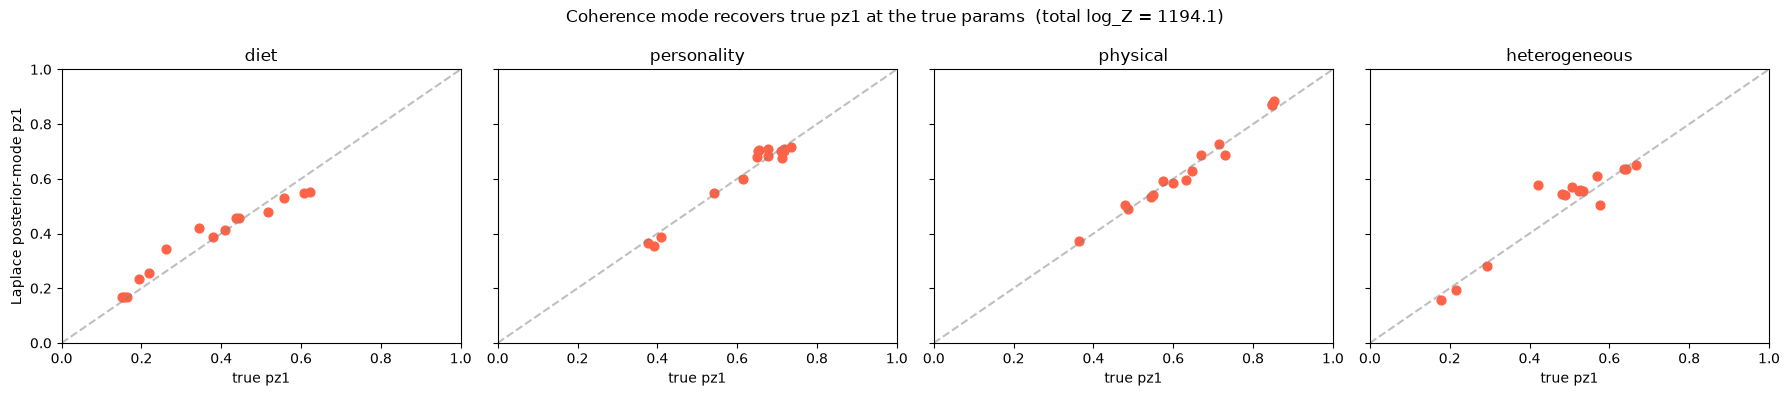

In [6]:
ref_cd = cond_data_for(ref_data)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
total_logZ = 0.0
for ax, c in zip(axes, CONDITIONS):
    logZ, y_hat, ok = laplace_log_Z(ref_cd[c], REF_LS, REF_MU)
    total_logZ += logZ
    pz1_mode = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    r_mode_true = np.corrcoef(ref_data['pz1_test_true_cond'][c], pz1_mode)[0, 1]
    print(f"  {c:<14}: log_Z={logZ:10.1f}  Hessian PD & converged={ok}  r(mode pz1, true pz1)={r_mode_true:+.3f}")
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
    ax.scatter(ref_data['pz1_test_true_cond'][c], pz1_mode, s=40, color='tomato')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('true pz1'); ax.set_title(c)
axes[0].set_ylabel('Laplace posterior-mode pz1')
fig.suptitle(f'Coherence mode recovers true pz1 at the true params  (total log_Z = {total_logZ:.1f})')
plt.tight_layout(); plt.show()


### Deterministic-objective check: is `log Z(theta)` smooth and peaked near the truth?

The whole reason for Laplace is a noise-free objective. Slice the summed `log Z` along each
parameter with the other held at truth.


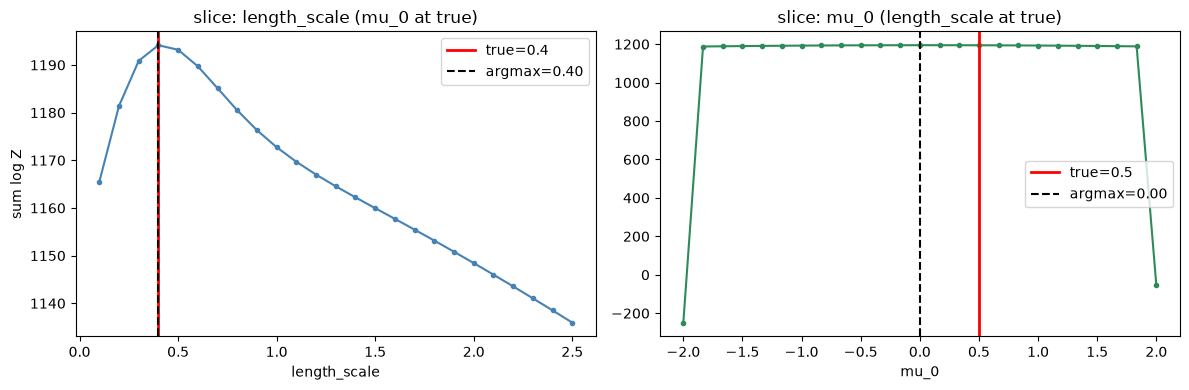

In [7]:
ls_grid = np.linspace(0.1, 2.5, 25)
mu_grid = np.linspace(-2.0, 2.0, 25)
ll_ls = np.array([total_log_lik(ref_data, ls, REF_MU) for ls in ls_grid])
ll_mu = np.array([total_log_lik(ref_data, REF_LS, mu) for mu in mu_grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ls_grid, ll_ls, '-o', ms=3, color='steelblue')
axes[0].axvline(REF_LS, color='red', lw=2, label=f"true={REF_LS}")
axes[0].axvline(ls_grid[np.argmax(ll_ls)], color='k', ls='--', label=f'argmax={ls_grid[np.argmax(ll_ls)]:.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_ylabel('sum log Z'); axes[0].set_title('slice: length_scale (mu_0 at true)'); axes[0].legend()
axes[1].plot(mu_grid, ll_mu, '-o', ms=3, color='seagreen')
axes[1].axvline(REF_MU, color='red', lw=2, label=f"true={REF_MU}")
axes[1].axvline(mu_grid[np.argmax(ll_mu)], color='k', ls='--', label=f'argmax={mu_grid[np.argmax(ll_mu)]:.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('slice: mu_0 (length_scale at true)'); axes[1].legend()
plt.tight_layout(); plt.show()


## 4. VBMC objective (deterministic, with a nominal target noise)

`log_joint(phi) = sum_c laplace_log_Z_c + log_prior(theta)`. Bounds widened vs. the original
notebook (`ls` hard bound 2.5 -> 4.0, plausible 1.0 -> 2.5) so the ls=2 sweep point isn't clipped.


In [8]:
MAX_EVALS    = 100
MAX_EVALS_1D = 60

# The Laplace objective is DETERMINISTIC, but we still declare a tiny observation noise to VBMC and
# run it with specify_target_noise=True. Two reasons:
#  (1) pyVBMC/gpyreg's EXACT-observation GP path has a noise-hyperparameter gradient bug that crashes
#      train_gp with "ValueError: setting an array element with a sequence" on this problem. The noisy
#      path avoids that code entirely.
#  (2) a small jitter regularizes the surrogate GP over the objective.
# TARGET_NOISE is tiny relative to the spread of log_joint, so it does not smear the posterior.
TARGET_NOISE = 1.0

def log_prior_ls(log_ls):  return float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
def log_prior_mu(mu_0):    return float(-0.5 * mu_0 ** 2)

# VBMC box for phi = [log_ls, mu_0]
X0  = np.array([np.log(0.3), 0.0])
LB  = np.array([np.log(0.03), -4.0])
UB  = np.array([np.log(4.0),   4.0])
PLB = np.array([np.log(0.08), -2.0])
PUB = np.array([np.log(2.5),   2.0])

def make_log_joint(data, counter=None, verbose=True):
    '''Full 2D objective for one dataset. phi = [log_ls, mu_0]; linking shapes fixed at truth.
    Returns (value, noise_std) because VBMC is run with specify_target_noise=True.'''
    counter = counter if counter is not None else [0]
    def log_joint(phi):
        phi = np.asarray(phi).ravel()
        log_ls, mu_0 = float(phi[0]), float(phi[1])
        ls = float(np.exp(log_ls))
        counter[0] += 1
        ll = total_log_lik(data, ls, mu_0)
        lp = log_prior_ls(log_ls) + log_prior_mu(mu_0)
        val = ll + lp
        if verbose:
            print(f"  eval {counter[0]:3d}: ls={ls:.3f}  mu_0={mu_0:+.3f}  log_lik={ll:.1f}  log_joint={val:.1f}")
        return val, TARGET_NOISE
    return log_joint

print(f"defined make_log_joint; linking shapes fixed at {TRUE_LINK_SHAPES}; target_noise={TARGET_NOISE}")


defined make_log_joint; linking shapes fixed at [8. 2. 2. 8.]; target_noise=1.0


## 5. One-off 1-D recoveries at the reference setting

Isolate each parameter (the other fixed at truth). If a parameter recovers well alone but not
jointly, the issue is the ridge/confound between them; if it fails even alone, it's individually
unidentifiable from this data.

### 5a. length_scale only (mu_0 fixed at true)


In [9]:
_n_ls = [0]
def log_joint_ls_only(phi):
    log_ls = float(np.asarray(phi).ravel()[0]); ls = float(np.exp(log_ls))
    _n_ls[0] += 1
    ll = total_log_lik(ref_data, ls, REF_MU)
    val = ll + log_prior_ls(log_ls)
    print(f"  [ls-only] {_n_ls[0]:3d}: ls={ls:.3f}  log_lik={ll:.1f}")
    return val, TARGET_NOISE

vbmc_ls = VBMC(log_joint_ls_only,
               np.array([np.log(1.5)]), np.array([LB[0]]), np.array([UB[0]]),
               np.array([PLB[0]]), np.array([PUB[0]]),
               options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS_1D})
res_ls, stats_ls = vbmc_ls.optimize()
ls_post = np.exp(res_ls.sample(int(1e4))[0][:, 0])
print(f"\nlengthscale-only:  true={REF_LS}   median={np.median(ls_post):.3f}   "
      f"95% CI [{np.percentile(ls_post,2.5):.3f}, {np.percentile(ls_post,97.5):.3f}]   ({stats_ls['convergence_status']})")


Reshaping x0 to row vector.


Reshaping lower bounds to (1, 1).


Reshaping upper bounds to (1, 1).


Reshaping plausible lower bounds to (1, 1).


Reshaping plausible upper bounds to (1, 1).


...

   inf         60        1192.92         0.12         0.00       50       1.06     finalize


Inference terminated: reached maximum number of function evaluations options.max_fun_evals.


Estimated ELBO: 1192.920 +/-0.124.


Caution: Returned variational solution may have not converged.



lengthscale-only:  true=0.4   median=0.405   95% CI [0.306, 0.533]   (no)


### 5b. mu_0 only (length_scale fixed at true)

In [10]:
_n_mu = [0]
def log_joint_mu_only(phi):
    mu_0 = float(np.asarray(phi).ravel()[0])
    _n_mu[0] += 1
    ll = total_log_lik(ref_data, REF_LS, mu_0)
    val = ll + log_prior_mu(mu_0)
    print(f"  [mu-only] {_n_mu[0]:3d}: mu_0={mu_0:+.3f}  log_lik={ll:.1f}")
    return val, TARGET_NOISE

vbmc_mu = VBMC(log_joint_mu_only,
               np.array([1.0]), np.array([LB[1]]), np.array([UB[1]]),
               np.array([PLB[1]]), np.array([PUB[1]]),
               options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS_1D})
res_mu, stats_mu = vbmc_mu.optimize()
mu0_post = res_mu.sample(int(1e4))[0][:, 0]
print(f"\nmu_0-only:  true={REF_MU}   median={np.median(mu0_post):.3f}   "
      f"95% CI [{np.percentile(mu0_post,2.5):.3f}, {np.percentile(mu0_post,97.5):.3f}]   ({stats_mu['convergence_status']})")


Reshaping x0 to row vector.


Reshaping lower bounds to (1, 1).


Reshaping upper bounds to (1, 1).


Reshaping plausible lower bounds to (1, 1).


Reshaping plausible upper bounds to (1, 1).


...

   inf         60        1194.66         0.15         0.00       50      0.169     finalize


Inference terminated: reached maximum number of function evaluations options.max_fun_evals.


Estimated ELBO: 1194.660 +/-0.148.


Caution: Returned variational solution may have not converged.



mu_0-only:  true=0.5   median=0.038   95% CI [-0.854, 0.913]   (no)


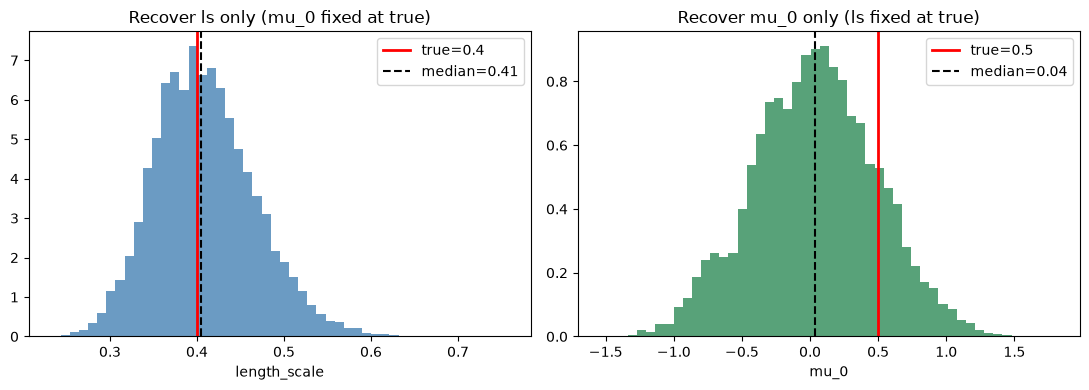

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ls_post, bins=50, density=True, color='steelblue', alpha=0.8)
axes[0].axvline(REF_LS, color='red', lw=2, label=f"true={REF_LS}")
axes[0].axvline(np.median(ls_post), color='k', ls='--', label=f'median={np.median(ls_post):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Recover ls only (mu_0 fixed at true)'); axes[0].legend()
axes[1].hist(mu0_post, bins=50, density=True, color='seagreen', alpha=0.8)
axes[1].axvline(REF_MU, color='red', lw=2, label=f"true={REF_MU}")
axes[1].axvline(np.median(mu0_post), color='k', ls='--', label=f'median={np.median(mu0_post):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Recover mu_0 only (ls fixed at true)'); axes[1].legend()
plt.tight_layout(); plt.show()


## 6. Sweep: joint (ls, mu_0) recovery across the grid

One synthetic dataset (seed=37) and one full 2-D VBMC fit per grid point. Results are written
incrementally to `results/param-recovery-vbmc-laplace/` — completed points are skipped on re-run,
so the sweep is resumable after an interruption.

Note ls=2.0 is deliberately OUTSIDE the identifiable regime (cloud diameter ~0.78) to see what
failure looks like.


In [12]:
import time, json

LS_VALUES = [0.2, 0.4, 0.6, 2.0]
MU_VALUES = [-0.5, 0.0, 0.5]
SWEEP_SEED = 37
RESULTS_DIR = os.path.join('results', 'param-recovery-vbmc-laplace')
os.makedirs(RESULTS_DIR, exist_ok=True)

def point_path(true_ls, true_mu):
    return os.path.join(RESULTS_DIR, f"ls{true_ls:g}_mu{true_mu:g}_seed{SWEEP_SEED}.npz")

def run_joint_recovery(true_ls, true_mu, seed=SWEEP_SEED, verbose_evals=False):
    '''Generate data at (true_ls, true_mu) and run the joint 2-D VBMC recovery. Returns dict.'''
    data = generate_data(true_ls, true_mu, seed=seed)
    t0 = time.time()
    vbmc = VBMC(make_log_joint(data, verbose=verbose_evals), X0, LB, UB, PLB, PUB,
                options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS})
    result, stats = vbmc.optimize()
    phi_samples, _ = result.sample(int(1e4))
    return {
        'true_ls': true_ls, 'true_mu': true_mu, 'seed': seed,
        'ls_samples':  np.exp(phi_samples[:, 0]),
        'mu0_samples': phi_samples[:, 1],
        'elbo': float(stats['elbo']), 'func_count': int(stats['func_count']),
        'convergence_status': str(stats['convergence_status']),
        'runtime_s': time.time() - t0,
    }

grid = [(ls, mu) for ls in LS_VALUES for mu in MU_VALUES]
for k, (ls, mu) in enumerate(grid, 1):
    path = point_path(ls, mu)
    if os.path.exists(path):
        print(f"[{k:2d}/{len(grid)}] ls={ls:g} mu={mu:+g}  -- already done, skipping")
        continue
    print(f"[{k:2d}/{len(grid)}] ls={ls:g} mu={mu:+g}  running...")
    out = run_joint_recovery(ls, mu)
    np.savez_compressed(path, **{k2: v for k2, v in out.items() if isinstance(v, np.ndarray)},
                        meta=json.dumps({k2: v for k2, v in out.items() if not isinstance(v, np.ndarray)}))
    print(f"     done in {out['runtime_s']:.0f}s  ({out['convergence_status']})  "
          f"ls median={np.median(out['ls_samples']):.3f}  mu median={np.median(out['mu0_samples']):+.3f}")


[ 1/12] ls=0.2 mu=-0.5  running...
Reshaping x0 to row vector.


Reshaping lower bounds to (1, 2).


Reshaping upper bounds to (1, 2).


Reshaping plausible lower bounds to (1, 2).


Reshaping plausible upper bounds to (1, 2).


...

   inf        100        1111.23         0.26         0.41       50       9.46     finalize


Inference terminated: reached maximum number of function evaluations options.max_fun_evals.


Estimated ELBO: 1111.226 +/-0.258.


Caution: Returned variational solution may have not converged.


     done in 156s  (no)  ls median=3.070  mu median=-0.114


## 7. Summary: recovered vs true across the grid

Posterior median with 95% CI at each grid point, against the identity line.


 true ls  true mu |          ls med [95% CI] |          mu med [95% CI] | status
     0.2     -0.5 |   0.180 [0.126, 0.226] |  -0.578 [-1.271, 0.161] | no
     0.2        0 |   0.176 [0.134, 0.214] |  -0.246 [-0.933, 0.499] | no
     0.2      0.5 |   0.185 [0.148, 0.224] |   0.274 [-0.533, 1.000] | no
     0.4     -0.5 |   0.404 [0.305, 0.527] |  -0.756 [-1.616, 0.129] | no
     0.4        0 |   0.382 [0.287, 0.507] |  -0.397 [-1.282, 0.496] | no
     0.4      0.5 |   0.415 [0.320, 0.532] |   0.024 [-0.855, 0.930] | no
     0.6     -0.5 |   0.727 [0.450, 1.165] |  -0.805 [-1.906, 0.233] | no
     0.6        0 |   0.700 [0.459, 1.055] |  -0.542 [-1.588, 0.412] | no
     0.6      0.5 |   0.581 [0.410, 0.840] |  -0.052 [-1.034, 0.844] | no
       2     -0.5 |   2.221 [1.261, 3.349] |  -0.681 [-1.757, 0.417] | no
       2        0 |   4.000 [2.311, 4.000] |   1.426 [-0.523, 1.464] | no
       2      0.5 |   3.070 [1.598, 3.822] |  -0.114 [-0.937, 1.011] | no


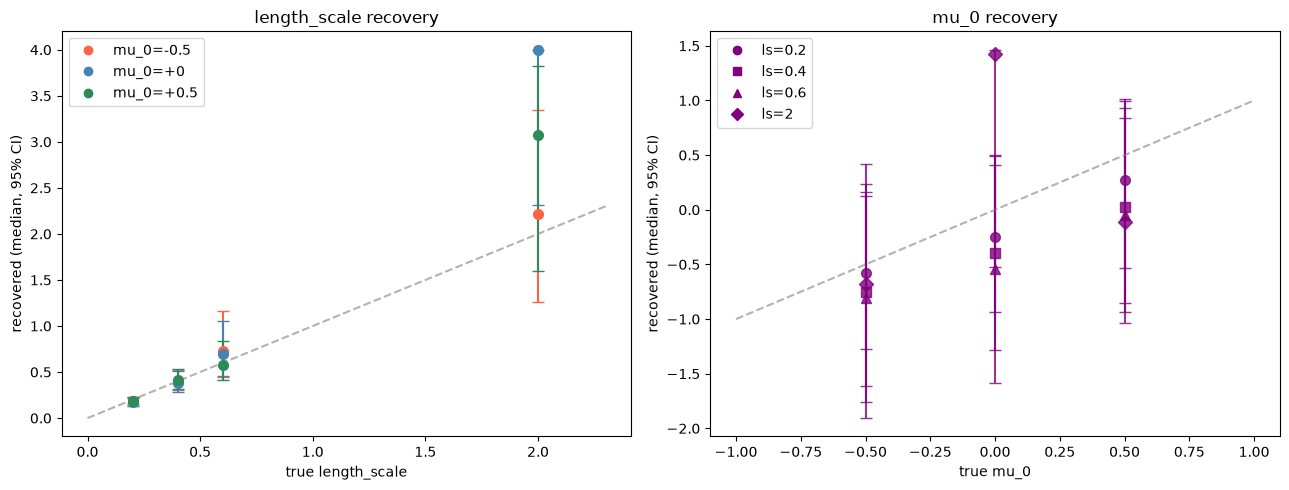

In [13]:
rows = []
for ls, mu in grid:
    path = point_path(ls, mu)
    if not os.path.exists(path):
        print(f"missing: ls={ls:g} mu={mu:+g} -- run the sweep cell first"); continue
    z = np.load(path, allow_pickle=True)
    meta = json.loads(str(z['meta']))
    rows.append({
        'true_ls': ls, 'true_mu': mu,
        'ls_med':  np.median(z['ls_samples']),  'ls_lo':  np.percentile(z['ls_samples'], 2.5),  'ls_hi':  np.percentile(z['ls_samples'], 97.5),
        'mu_med':  np.median(z['mu0_samples']), 'mu_lo':  np.percentile(z['mu0_samples'], 2.5), 'mu_hi':  np.percentile(z['mu0_samples'], 97.5),
        'status': meta['convergence_status'],
    })

print(f"{'true ls':>8}{'true mu':>9} | {'ls med [95% CI]':>24} | {'mu med [95% CI]':>24} | status")
for r in rows:
    print(f"{r['true_ls']:>8g}{r['true_mu']:>9g} | {r['ls_med']:>7.3f} [{r['ls_lo']:.3f}, {r['ls_hi']:.3f}] | "
          f"{r['mu_med']:>7.3f} [{r['mu_lo']:.3f}, {r['mu_hi']:.3f}] | {r['status']}")

mu_colors = {mu: col for mu, col in zip(MU_VALUES, ['tomato', 'steelblue', 'seagreen'])}
ls_markers = {ls: m for ls, m in zip(LS_VALUES, ['o', 's', '^', 'D'])}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# ls recovery, colored by true mu
for r in rows:
    col = mu_colors[r['true_mu']]
    axes[0].errorbar(r['true_ls'], r['ls_med'], yerr=[[r['ls_med']-r['ls_lo']], [r['ls_hi']-r['ls_med']]],
                     fmt='o', color=col, capsize=4, ms=7)
lim = max(LS_VALUES) * 1.15
axes[0].plot([0, lim], [0, lim], '--', color='gray', alpha=0.6)
axes[0].set_xlabel('true length_scale'); axes[0].set_ylabel('recovered (median, 95% CI)')
axes[0].set_title('length_scale recovery')
axes[0].legend(handles=[plt.Line2D([], [], marker='o', ls='', color=c, label=f'mu_0={m:+g}')
                        for m, c in mu_colors.items()])
# mu recovery, marker by true ls
for r in rows:
    axes[1].errorbar(r['true_mu'], r['mu_med'], yerr=[[r['mu_med']-r['mu_lo']], [r['mu_hi']-r['mu_med']]],
                     fmt=ls_markers[r['true_ls']], color='purple', capsize=4, ms=7, alpha=0.8)
axes[1].plot([-1, 1], [-1, 1], '--', color='gray', alpha=0.6)
axes[1].set_xlabel('true mu_0'); axes[1].set_ylabel('recovered (median, 95% CI)')
axes[1].set_title('mu_0 recovery')
axes[1].legend(handles=[plt.Line2D([], [], marker=mk, ls='', color='purple', label=f'ls={l:g}')
                        for l, mk in ls_markers.items()])
plt.tight_layout(); plt.show()
